t‑SNE: нелинейное вложение, оптимизирует дивергенцию Кульбака–Лейблера между распределениями близостей точек, хорошо показывает локальные кластеры, но медленно, плохо сохраняет глобальные расстояния, чувствительно к perplexity и random_state.

UMAP: основан на теории многобразий и топологии, строит взвешенный граф соседей и оптимизирует кросс‑энтропию; быстрее t‑SNE, лучше сохраняет глобальную структуру, более устойчив к малым изменениям параметров (n_neighbors, min_dist).

TriMAP: ориентирован на сохранение глобальной структуры через тройки точек (anchor, сосед, далёкий), улучшает глобальное расположение кластеров при сохранении локальной структуры.

PaCMAP: управляет соотношением близких, средних и далёких пар, чтобы одновременно хорошо держать локальные кластеры и общую форму; показывает хорошие результаты на омикс‑данных и эмбеддингах.

PHATE: использует диффузионные процессы и потенциал для визуализации непрерывных траекторий (например, дифференцировка клеток), хорошо показывает как кластеры, так и переходы между ними.



In [ ]:
%pip install umap-learn trimap pacmap phate scikit-learn seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

from sklearn.manifold import TSNE
import umap
import trimap
import pacmap
import phate



In [3]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names_iris = iris.feature_names
print(X_iris.shape, np.unique(y_iris))


(150, 4) [0 1 2]


In [ ]:
path = "my_data.csv"  # замените на свой путь
df = pd.read_csv(path)
df.head()


In [ ]:
feature_cols = [c for c in df.columns if c != "target"]
X_own = df[feature_cols].values
y_own = df["target"].values
print(X_own.shape, len(np.unique(y_own)))


In [5]:
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)
 


Функции для DR и оценки разделения

In [ ]:
def run_tsne(X, random_state=42, perplexity=30, learning_rate=200, n_iter=1000):
    tsne = TSNE(
        ваш_код
    )
    return tsne.fit_transform(X)

def run_umap(X, random_state=42, n_neighbors=15, min_dist=0.1):
   ваш_код
    return reducer.fit_transform(X)

def run_trimap(X, random_state=42, n_inliers=10, n_outliers=5):
    ваш_код
    return reducer.fit_transform(X)

def run_pacmap(X, random_state=42, n_neighbors=10):
   ваш_код
    return reducer.fit_transform(X)

def run_phate(X, random_state=42, knn=15):
    ваш_код
    return phate_op.fit_transform(X)


Функция оценки качества разделения

In [7]:
def separation_score(X_2d, y):
    D = pairwise_distances(X_2d)
    same = D[y[:, None] == y[None, :]]
    diff = D[y[:, None] != y[None, :]]
    return same.mean(), diff.mean(), diff.mean() / same.mean()


In [8]:
# Отрисовка

def plot_embedding(X_2d, y, title):
    plt.figure(figsize=(6, 5))
    sns.scatterplot(
        x=X_2d[:, 0],
        y=X_2d[:, 1],
        hue=y,
        palette="tab10",
        s=30,
        legend="full"
    )
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.legend(title="Класс", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


e:\fmi-ml-courses\clusters\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Calculating PHATE...
  Running PHATE on 150 observations and 4 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.01 seconds.
    Calculating affinities...


e:\fmi-ml-courses\clusters\.venv\Lib\site-packages\graphtools\graphs.py:803: RuntimeWarning: Detected zero distance between samples 101 and 142. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


    Calculated affinities in 0.99 seconds.
  Calculated graph and diffusion operator in 1.01 seconds.
  Calculating optimal t...
    Automatically selected t = 22
  Calculated optimal t in 0.03 seconds.
  Calculating diffusion potential...
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by -1.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 0.13 seconds.
Calculated PHATE in 1.19 seconds.


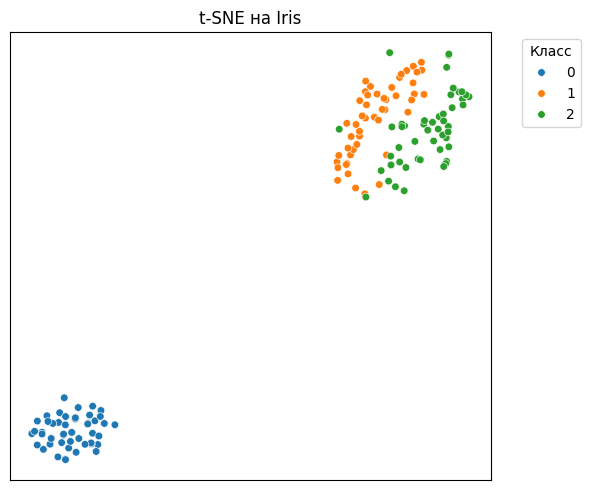

t-SNE: внутрикласс.=3.585, межкласс.=27.427, ratio=7.650


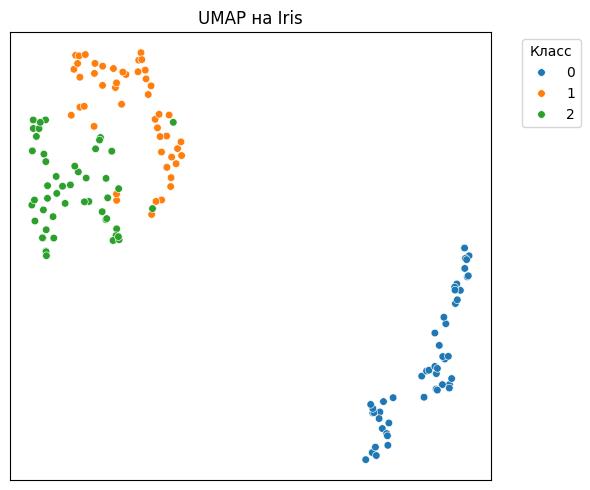

UMAP: внутрикласс.=1.902, межкласс.=10.504, ratio=5.524


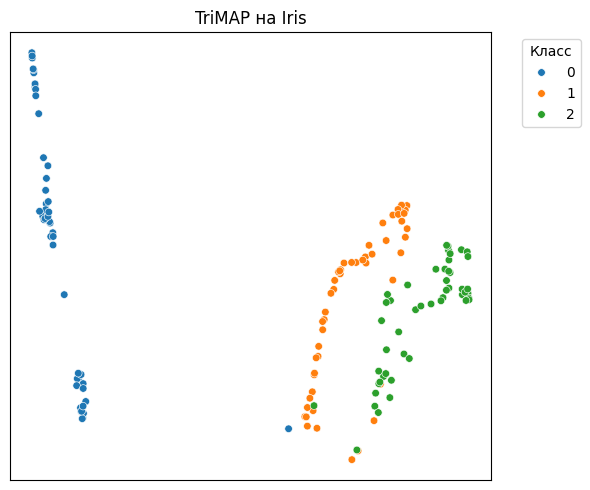

TriMAP: внутрикласс.=11.270, межкласс.=60.575, ratio=5.375


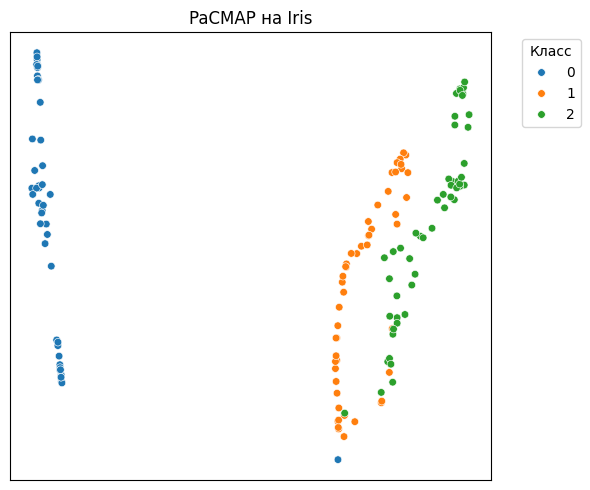

PaCMAP: внутрикласс.=3.471, межкласс.=17.697, ratio=5.099


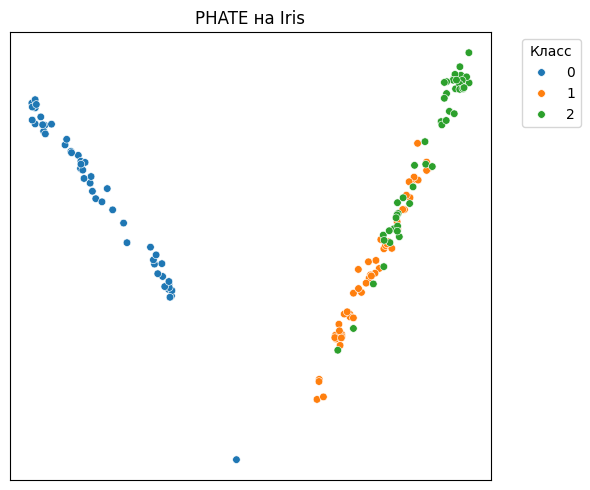

PHATE: внутрикласс.=0.026, межкласс.=0.121, ratio=4.610


In [ ]:
X_list = []
names = []

X_tsne_iris = run_tsne(X_iris_scaled, random_state=42)
X_list.append(X_tsne_iris); names.append("t-SNE")

X_umap_iris = run_umap(X_iris_scaled, random_state=42)
X_list.append(X_umap_iris); names.append("UMAP")

"TriMAP"

"PaCMAP"

"PHATE"

for X_emb, name in zip(X_list, names):
    plot_embedding(X_emb, y_iris, f"{name} на Iris")
    same, diff, ratio = separation_score(X_emb, y_iris)
    print(
        f"{name}: внутрикласс.={same:.3f}, межкласс.={diff:.3f}, ratio={ratio:.3f}"
    )


Сравнение устойчивости

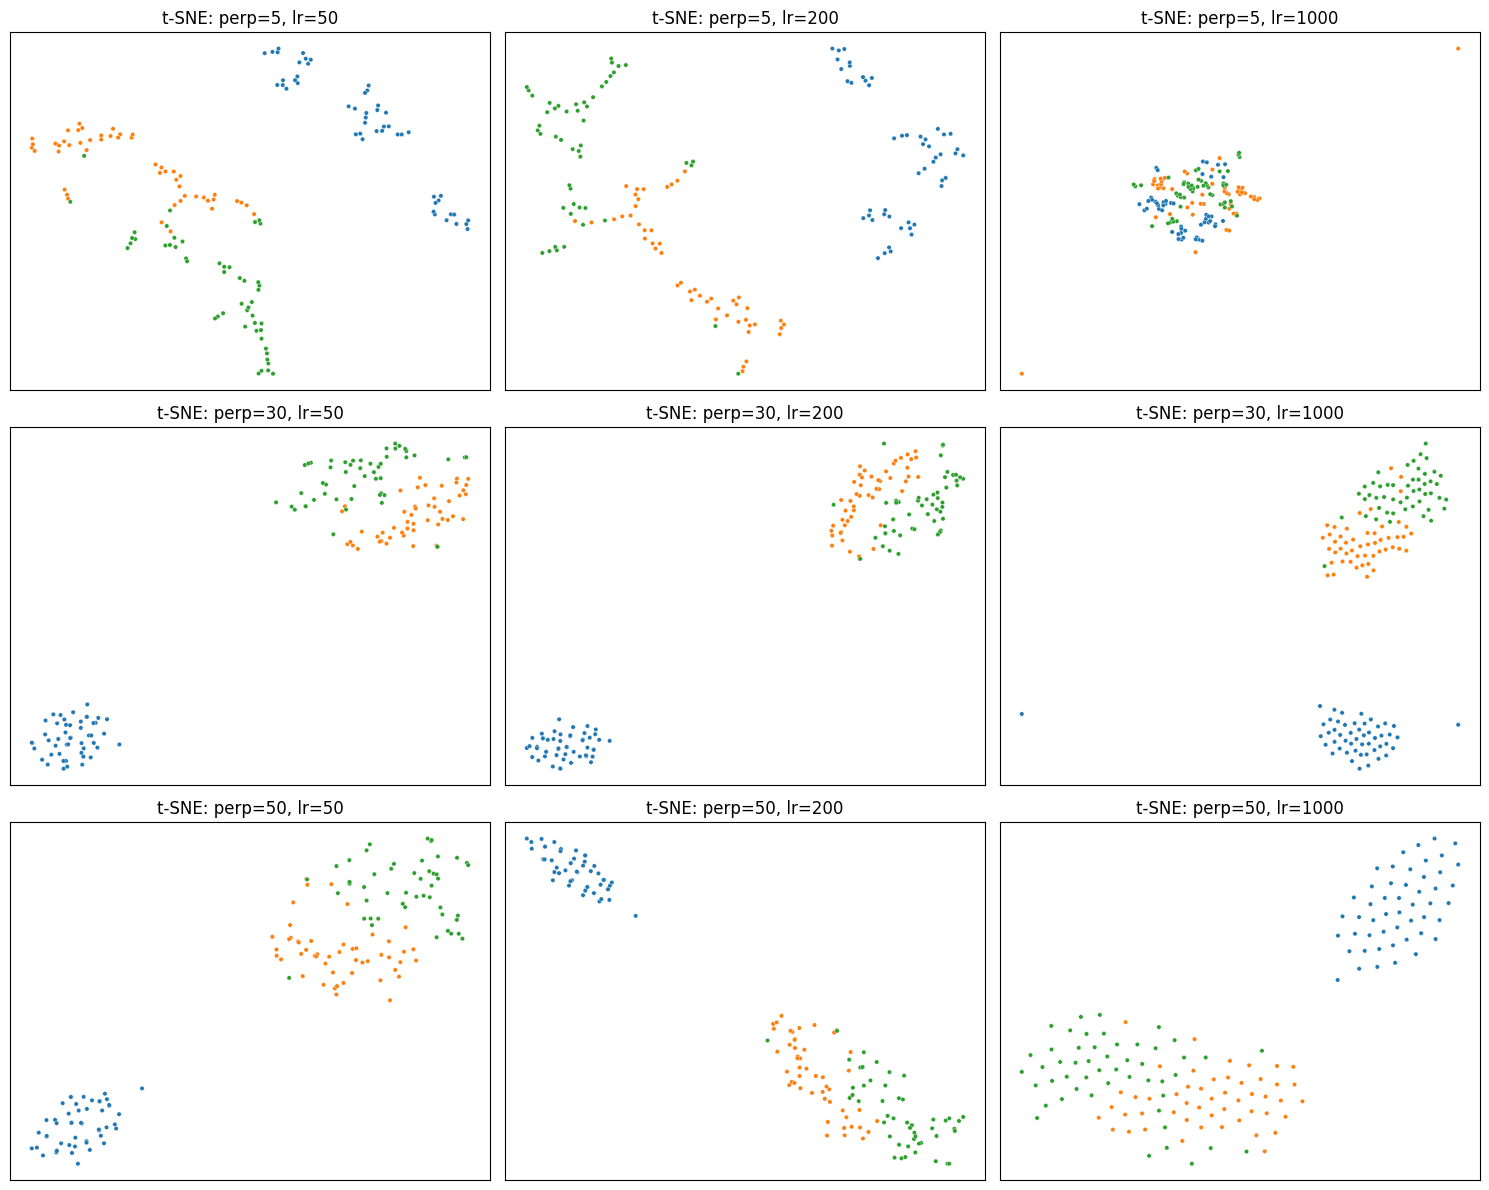

In [18]:
perplexities = [5, 30, 50]
lrs = [50, 200, 1000]

fig, axes = plt.subplots(len(perplexities), len(lrs), figsize=(5*len(lrs), 4*len(perplexities)))

for i, perp in enumerate(perplexities):
    for j, lr in enumerate(lrs):
        X_emb = run_tsne(X_iris_scaled, random_state=42, perplexity=perp, learning_rate=lr)
        ax = axes[i, j]
        sns.scatterplot(x=X_emb[:, 0], y=X_emb[:, 1], hue=y_iris, palette="tab10", s=10, ax=ax, legend=False)
        ax.set_title(f"t-SNE: perp={perp}, lr={lr}")
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()


Нужно описать, как меняется форма и расположение кластеров при разных perplexity и learning_rate и что визуализация t‑SNE может сильно меняться.

e:\fmi-ml-courses\clusters\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
e:\fmi-ml-courses\clusters\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
e:\fmi-ml-courses\clusters\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
e:\fmi-ml-courses\clusters\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
e:\fmi-ml-courses\clusters\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
e:\fmi-ml-courses\clusters\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 

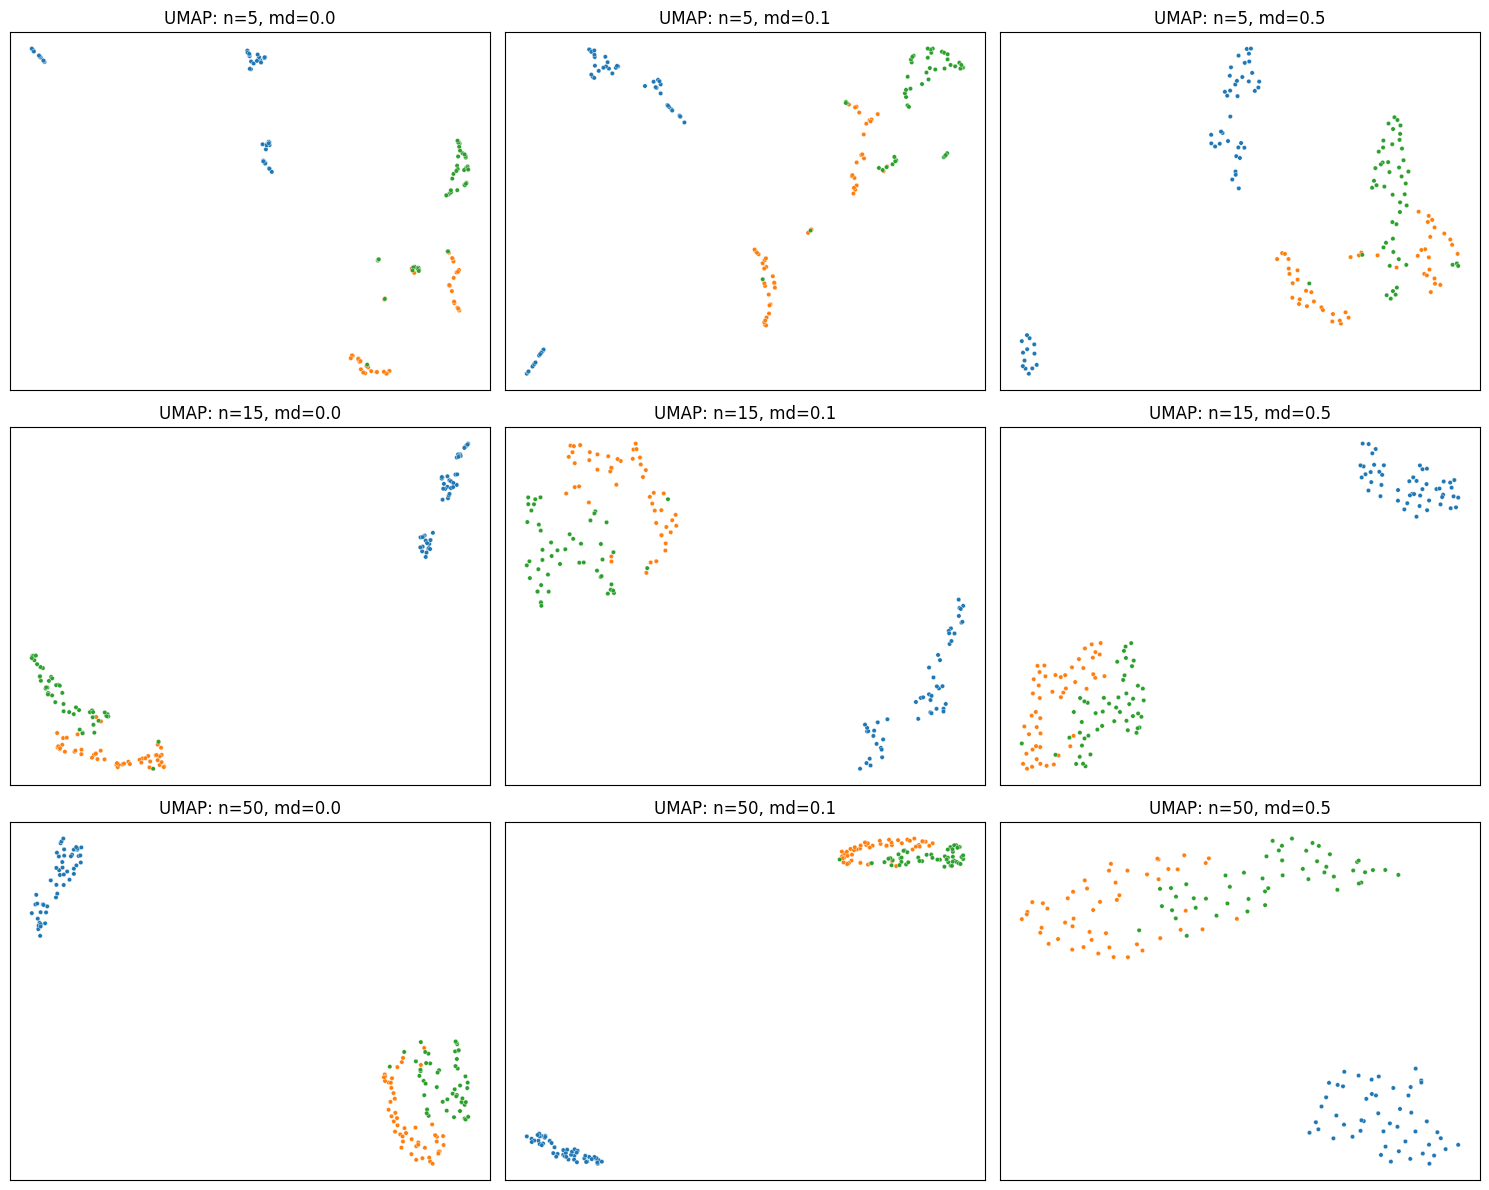

In [ ]:
"UMAP....

Обычно структура UMAP меняется плавнее, кластеры остаются узнаваемыми при разумном диапазоне параметров.

*Задача* Аналогично нужно сделать по одной строке графиков для TriMAP, PaCMAP, PHATE с варьированием ключевого параметра (количество соседей или похожий гиперпараметр) и показать, насколько устойчив рисунок.



| Метод  | Скорость на больших данных                   | Локальное разделение              | Глобальная структура                            | Чувствительность к параметрам                         | Комментарий                                        |
| ------ | -------------------------------------------- | --------------------------------- | ----------------------------------------------- | ----------------------------------------------------- | -------------------------------------------------- |
| t‑SNE  | Низкая l                    | Отличное                   | Слабая                                   | Высокая (perplexity, lr, random_state) aicompetence+2 | Хорошо для локальных кластеров, тяжёлый тюнинг     |
| UMAP   | Высокая l                   | Очень хорошее   | Лучшая, чем у t‑SNE           | Ниже, чем у t‑SNE aicompetence+2                      | Хороший баланс локал/глобал, удобен в практике     |
| TriMAP | Средняя                              | Хорошее                   | Сильный упор на глобальную структуру    | Умеренная                                     | Лучше показывает относительное положение кластеров |
| PaCMAP | Средняя                               | Отличное                   | Хорошее                                  | Умеренная                                      | Часто даёт чёткие кластеры и форму многобразия     |
| PHATE  | Средняя/низкая (зависит от размера)   | Хорошее        | Очень хорошее, особенно для траекторий   | Умеренная                          | Сильный метод для непрерывных переходов            |

# Варианты препроцессинга
*Задача* — явно сравнить, как UMAP и t‑SNE реагируют на разные варианты нормировки и отбора признаков.

## Определяем три сценария
Без масштабирования (сырой набор признаков).

StandardScaler (z‑нормировка).

MinMaxScaler + отбор признаков по дисперсии (эмуляция feature selection).

Задание. Проделать все три сценария. Обучить все модели при разных сценария кластеризации. 
Нужно в результате:
1. описать, какие признаки были отброшены и почему это может влиять на качество кластеризации во вложенном пространстве.
1. сравнить вычислительное время и сделать вывод о масштабируемости методов
1. изменить гиперпараметры (perplexity, n_neighbors, min_dist) и исследовать совместное влияние гиперпараметров и препроцессинга на структуру кластеров.
